# Data Cleaning and Feature Extraction

This notebook prepares the multilingual speech dataset for modeling.

Workflow:
1. Locate and index audio files.
2. Apply cleaning (mono, 16 kHz, normalize, trim silence).
3. Inspect sample waveforms and durations.
4. Extract fixed-length acoustic features and cache them to CSV.

In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import PROJECT_ROOT, resolve_dataset_dir
from src.data import (
    build_feature_dataframe,
    clean_audio,
    find_audio_files,
    load_audio,
    summarize_by_language,
)

In [2]:
dataset_dir = resolve_dataset_dir()
dataset_dir

PosixPath('/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset')

## Dataset index

In [3]:
records = find_audio_files(dataset_dir)
print(f"Total files: {len(records)}")
index_df = pd.DataFrame(records)
index_df["language"].value_counts().sort_index()

Total files: 720


language
German     180
Italian    180
Korean     180
Spanish    180
Name: count, dtype: int64

## Cleaning preview

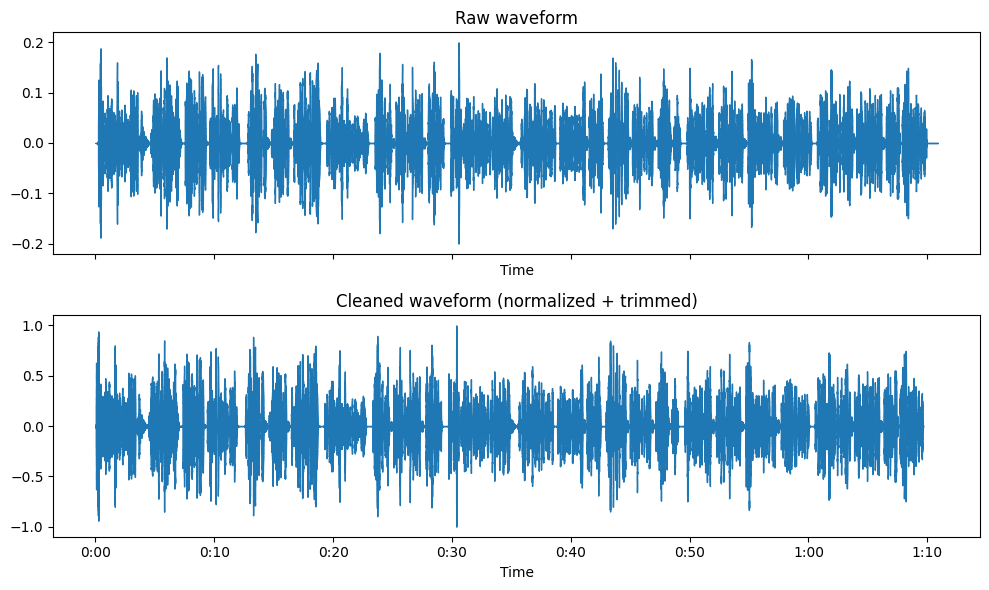

In [4]:
sample_path = records[0]["path"]
y, sr = load_audio(sample_path)
y_clean = clean_audio(y, sr)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title("Raw waveform")
librosa.display.waveshow(y_clean, sr=sr, ax=axes[1])
axes[1].set_title("Cleaned waveform (normalized + trimmed)")
plt.tight_layout()

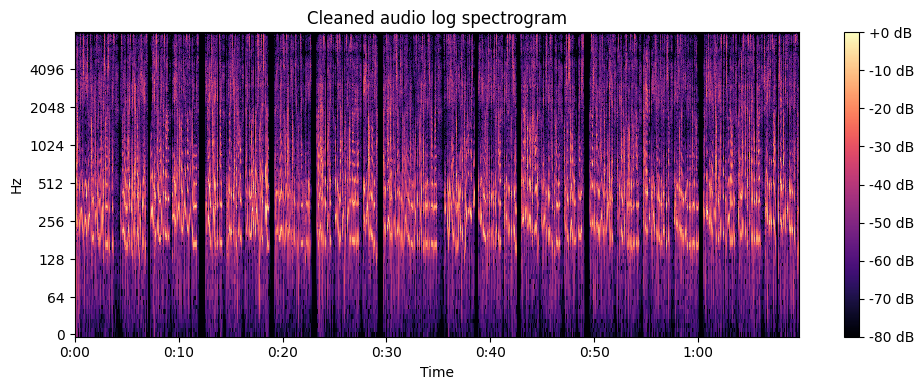

In [5]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Cleaned audio log spectrogram")
plt.tight_layout()

## Duration sanity check (sample)

In [6]:
sample_size = 50  # set to None to process the full dataset

duration_rows = []
for language in sorted(index_df["language"].unique()):
    lang_rows = index_df[index_df["language"] == language]
    if sample_size:
        lang_rows = lang_rows.head(sample_size)
    for row in lang_rows.to_dict("records"):
        y, sr = load_audio(row["path"])
        y = clean_audio(y, sr)
        duration_rows.append({"language": language, "duration_sec": len(y) / sr})

durations_df = pd.DataFrame(duration_rows)
durations_df.groupby("language")["duration_sec"].describe()

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
German,50.0,59.769169,5.007163,43.712000,57.200,59.472000,62.107578,75.3015
Italian,50.0,89.082909,208.410124,47.136000,57.368,59.962656,62.144000,1533.0240
Korean,50.0,60.484527,4.202817,51.042375,57.920,59.776000,62.656000,72.6720
Spanish,50.0,60.560425,6.143491,42.574813,56.624,60.496000,64.744000,74.1120


## Feature extraction

We extract MFCCs (plus deltas), spectral features, RMS, ZCR, spectral contrast, and chroma.
Features are aggregated with mean and standard deviation to form fixed-length vectors.

In [7]:
features_path = PROJECT_ROOT / "data" / "processed" / "features.csv"
limit = None  # set to an int for a quick run

if features_path.exists():
    features_df = pd.read_csv(features_path)
    failures = []
else:
    features_df, failures = build_feature_dataframe(
        dataset_dir,
        cache_path=features_path,
        limit=limit,
    )

features_df.head()

,path,language,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,chroma_8_mean,chroma_8_std,chroma_9_mean,chroma_9_std,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std
0,/home/parsa/Downloads/Personal Projects/ML/Pha...,German,-192.995773,109.879951,53.943947,52.765930,8.191157,33.113358,15.328035,28.655838,...,0.340841,0.310585,0.406003,0.339836,0.431263,0.360957,0.401707,0.356789,0.336028,0.320749
1,/home/parsa/Downloads/Personal Projects/ML/Pha...,German,-199.990417,114.609032,69.736443,54.331131,8.218270,31.201180,12.784968,27.417326,...,0.400193,0.342056,0.428697,0.364610,0.377916,0.353806,0.334197,0.349251,0.261253,0.307608
2,/home/parsa/Downloads/Personal Projects/ML/Pha...,German,-244.625763,165.599899,59.306290,53.582386,13.063251,31.127668,14.088329,25.287489,...,0.417641,0.335166,0.455131,0.341320,0.459858,0.338419,0.451374,0.330251,0.416494,0.324328
3,/home/parsa/Downloads/Personal Projects/ML/Pha...,German,-231.909195,156.672348,70.347755,49.186863,9.129018,32.775822,11.279583,27.490608,...,0.436225,0.337539,0.456508,0.339206,0.459850,0.337000,0.442061,0.320271,0.408678,0.333273
4,/home/parsa/Downloads/Personal Projects/ML/Pha...,German,-291.841827,167.844421,65.041977,56.475201,8.817369,30.642347,11.118629,25.200415,...,0.391955,0.343439,0.417013,0.354985,0.433441,0.349945,0.442804,0.341854,0.406725,0.339916


In [8]:
summarize_by_language(features_df)

language
German     180
Italian    180
Korean     180
Spanish    180
Name: count, dtype: int64

In [9]:
feature_cols = [c for c in features_df.columns if c not in ("path", "language")]
len(feature_cols), feature_cols[:10]

(126,
 ['mfcc_1_mean',
  'mfcc_1_std',
  'mfcc_2_mean',
  'mfcc_2_std',
  'mfcc_3_mean',
  'mfcc_3_std',
  'mfcc_4_mean',
  'mfcc_4_std',
  'mfcc_5_mean',
  'mfcc_5_std'])

In [10]:
len(failures), failures[:5]

(0, [])